In [1]:
from pydataxm.pydataxm import ReadDB
import pandas as pd

obj = ReadDB()
variables = obj.all_variables()

# Filtrar las relacionadas con embalses
embalses = variables[variables['MetricId'].str.contains(
    'mbal|olum|Hidro|Apor', case=False, na=False
)]

print(embalses[['MetricId', 'MetricName', 'Entity']].to_string())

               MetricId                                   MetricName   Entity
120            AporEner                 Aportes  Energía por Sistema  Sistema
131    AporEnerMediHist  Aportes Media Histórica Energía por Sistema  Sistema
141            AporEner                     Aportes  Energía por Rio      Rio
142    AporEnerMediHist      Aportes Media Histórica Energía por Rio      Rio
152          AporCaudal                       Aportes Caudal por Rio      Rio
153  AporCaudalMediHist       Aportes Media Histórica Caudal por Rio      Rio
164            PorcApor                        Aportes % por Sistema  Sistema
165            PorcApor                            Aportes % por Rio      Rio
190     ListadoEmbalses              Listado de embalses por Sistema  Sistema


In [9]:
from datetime import datetime

print("Descargando aportes % del sistema 2010-2026...")
df_apor = obj.request_data(
    "PorcApor",
    "Sistema",
    datetime(2010, 1, 1),
    datetime(2026, 6, 1)
)

print("Shape:", df_apor.shape)
print("Columnas:", df_apor.columns.tolist())
print(df_apor.head(10))

Descargando aportes % del sistema 2010-2026...
Shape: (6027, 3)
Columnas: ['Id', 'Value', 'Date']
        Id    Value       Date
0  Sistema  0.60716 2010-01-01
1  Sistema  0.57363 2010-01-02
2  Sistema  0.57767 2010-01-03
3  Sistema  0.53787 2010-01-04
4  Sistema  0.54826 2010-01-05
5  Sistema  0.55548 2010-01-06
6  Sistema  0.52884 2010-01-07
7  Sistema  0.49352 2010-01-08
8  Sistema  0.62417 2010-01-09
9  Sistema  0.59772 2010-01-10


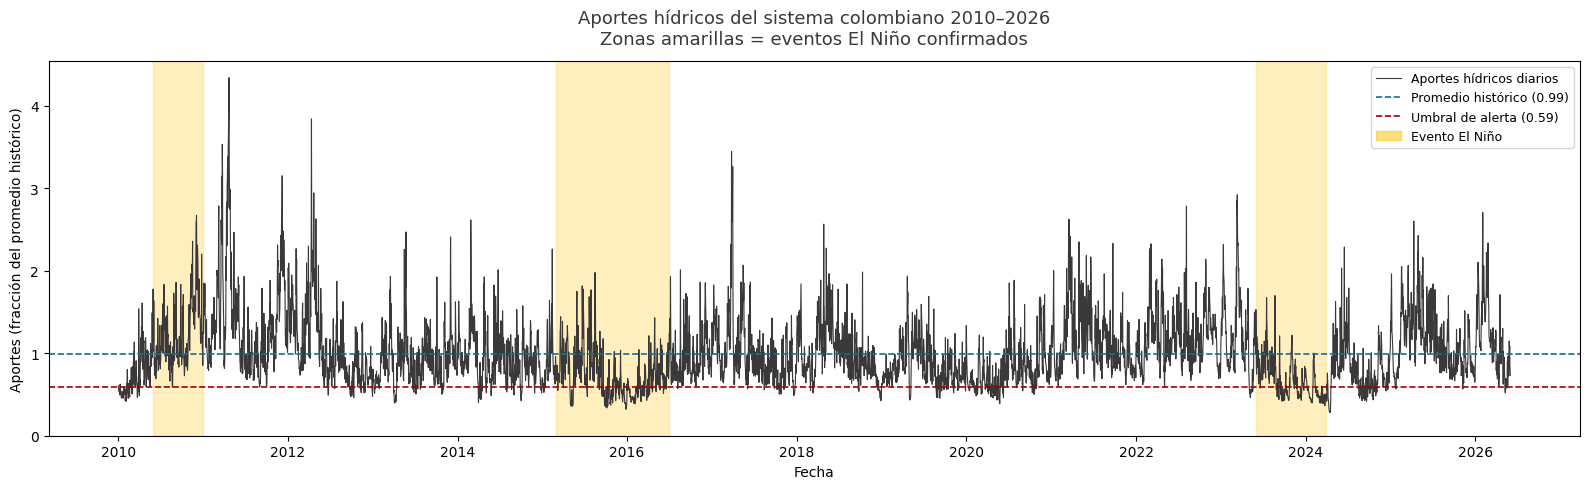

Gráfica guardada en outputs/aportes_enos.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Preparar datos
df_apor['Date'] = pd.to_datetime(df_apor['Date'])
df_apor = df_apor.sort_values('Date').reset_index(drop=True)

# Períodos El Niño confirmados en Colombia
nino = [
    ("2010-06-01", "2010-12-31"),
    ("2015-03-01", "2016-06-30"),
    ("2023-06-01", "2024-03-31"),
]

fig, ax = plt.subplots(figsize=(16, 5))

# Línea principal
ax.plot(df_apor['Date'], df_apor['Value'], 
        color='#3A3838', linewidth=0.8, label='Aportes hídricos diarios')

# Promedio histórico
promedio = df_apor['Value'].mean()
ax.axhline(promedio, color='#1F6B8E', linewidth=1.2, 
           linestyle='--', label=f'Promedio histórico ({promedio:.2f})')

# Umbral de alerta
umbral = promedio * 0.6
ax.axhline(umbral, color='#A00000', linewidth=1.2, 
           linestyle='--', label=f'Umbral de alerta ({umbral:.2f})')

# Sombrear períodos ENOS
for inicio, fin in nino:
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin),
               alpha=0.25, color='#FFC000')

# Leyenda manual para ENOS
nino_patch = mpatches.Patch(color='#FFC000', alpha=0.5, label='Evento El Niño')
ax.legend(handles=[*ax.get_legend_handles_labels()[0], nino_patch], 
          fontsize=9)

ax.set_title('Aportes hídricos del sistema colombiano 2010–2026\n'
             'Zonas amarillas = eventos El Niño confirmados', 
             fontsize=13, color='#3A3838', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Aportes (fracción del promedio histórico)')
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('../outputs/aportes_enos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en outputs/aportes_enos.png")

Días en El Niño:  1007
Días normales:    5020

Promedio El Niño:  0.820
Promedio normal:   1.021

Mediana El Niño:   0.734
Mediana normal:    0.927


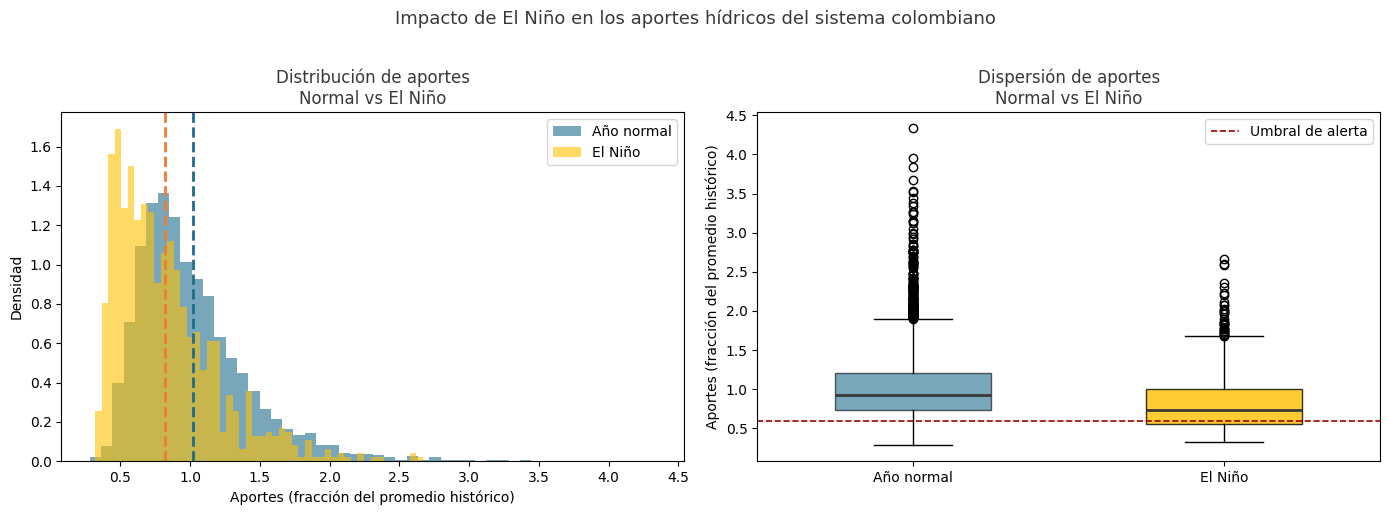

Gráfica guardada.


In [12]:
import numpy as np

# Clasificar días según fase ENOS
nino_periodos = [
    ("2010-06-01", "2010-12-31"),
    ("2015-03-01", "2016-06-30"),
    ("2023-06-01", "2024-03-31"),
]

def es_nino(fecha):
    for inicio, fin in nino_periodos:
        if pd.Timestamp(inicio) <= fecha <= pd.Timestamp(fin):
            return True
    return False

df_apor['es_nino'] = df_apor['Date'].apply(es_nino)

dias_nino   = df_apor[df_apor['es_nino'] == True]['Value']
dias_normal = df_apor[df_apor['es_nino'] == False]['Value']

print(f"Días en El Niño:  {len(dias_nino)}")
print(f"Días normales:    {len(dias_normal)}")
print(f"\nPromedio El Niño:  {dias_nino.mean():.3f}")
print(f"Promedio normal:   {dias_normal.mean():.3f}")
print(f"\nMediana El Niño:   {dias_nino.median():.3f}")
print(f"Mediana normal:    {dias_normal.median():.3f}")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparativo
axes[0].hist(dias_normal, bins=50, alpha=0.6, 
             color='#1F6B8E', label='Año normal', density=True)
axes[0].hist(dias_nino, bins=50, alpha=0.6, 
             color='#FFC000', label='El Niño', density=True)
axes[0].axvline(dias_normal.mean(), color='#1F6B8E', 
                linewidth=2, linestyle='--')
axes[0].axvline(dias_nino.mean(), color='#ED7D31', 
                linewidth=2, linestyle='--')
axes[0].set_title('Distribución de aportes\nNormal vs El Niño', 
                  fontsize=12, color='#3A3838')
axes[0].set_xlabel('Aportes (fracción del promedio histórico)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Boxplot comparativo
data_box = [dias_normal.values, dias_nino.values]
bp = axes[1].boxplot(data_box, labels=['Año normal', 'El Niño'],
                     patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#1F6B8E')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#FFC000')
bp['boxes'][1].set_alpha(0.8)
for median in bp['medians']:
    median.set_color('#3A3838')
    median.set_linewidth(2)

axes[1].axhline(0.59, color='#A00000', linewidth=1.2,
                linestyle='--', label='Umbral de alerta')
axes[1].set_title('Dispersión de aportes\nNormal vs El Niño',
                  fontsize=12, color='#3A3838')
axes[1].set_ylabel('Aportes (fracción del promedio histórico)')
axes[1].legend()

plt.suptitle('Impacto de El Niño en los aportes hídricos del sistema colombiano',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/distribucion_nino_vs_normal.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

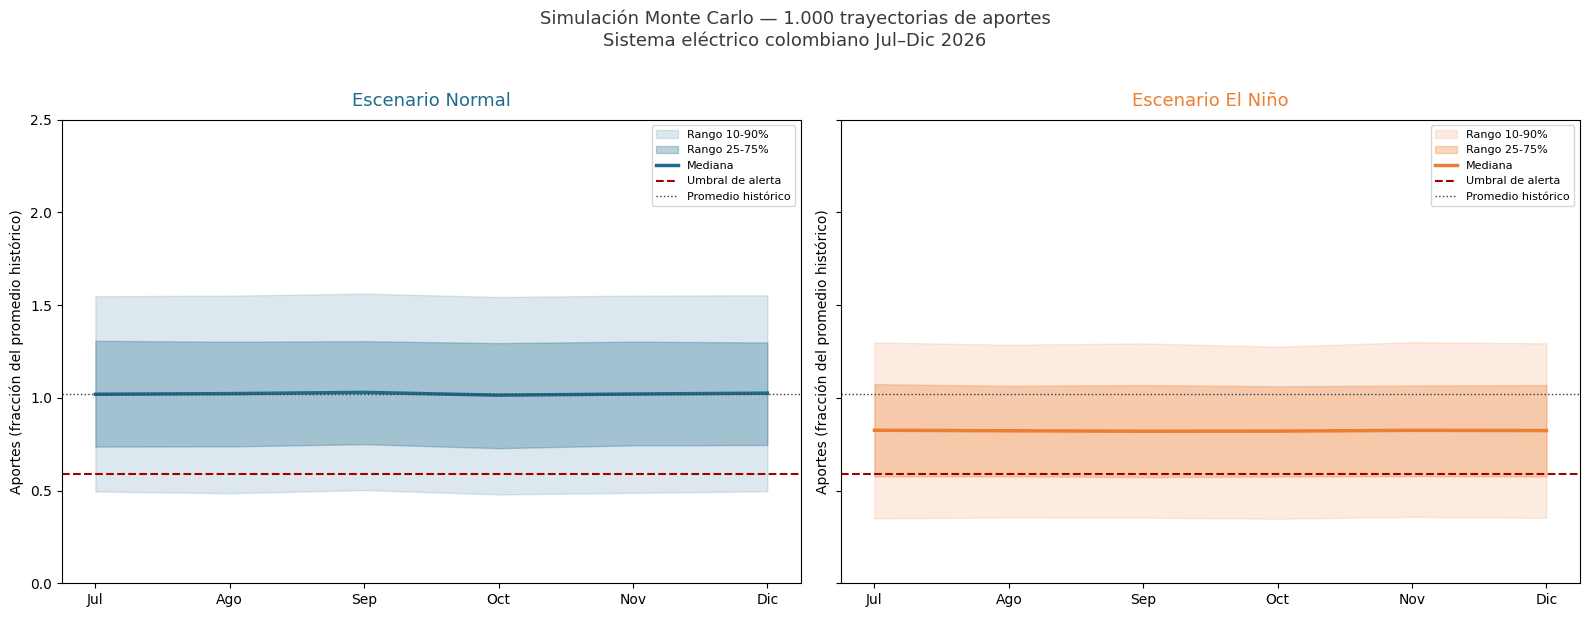

Gráfica guardada.


In [20]:
np.random.seed(42)
N_simulaciones = 10000
N_meses = 6
meses = ['Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Parámetros históricos por fase
media_normal = dias_normal.mean()
std_normal   = dias_normal.std()

media_nino   = dias_nino.mean()
std_nino     = dias_nino.std()

# Simular trayectorias
sim_normal = np.random.normal(media_normal, std_normal, 
                               (N_simulaciones, N_meses))
sim_nino   = np.random.normal(media_nino, std_nino, 
                               (N_simulaciones, N_meses))

# Clip para que no haya valores negativos
sim_normal = np.clip(sim_normal, 0, None)
sim_nino   = np.clip(sim_nino,   0, None)

# Gráfica abanico
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, sim, titulo, color in zip(
    axes,
    [sim_normal, sim_nino],
    ['Escenario Normal', 'Escenario El Niño'],
    ['#1F6B8E', '#ED7D31']
):
    # Percentiles
    p10 = np.percentile(sim, 10, axis=0)
    p25 = np.percentile(sim, 25, axis=0)
    p50 = np.percentile(sim, 50, axis=0)
    p75 = np.percentile(sim, 75, axis=0)
    p90 = np.percentile(sim, 90, axis=0)

    x = range(N_meses)

    ax.fill_between(x, p10, p90, alpha=0.15, color=color, label='Rango 10-90%')
    ax.fill_between(x, p25, p75, alpha=0.30, color=color, label='Rango 25-75%')
    ax.plot(x, p50, color=color, linewidth=2.5, label='Mediana')
    ax.axhline(0.59, color='#A00000', linewidth=1.5,
               linestyle='--', label='Umbral de alerta')
    ax.axhline(media_normal, color='#3A3838', linewidth=1,
               linestyle=':', label='Promedio histórico')

    ax.set_xticks(range(N_meses))
    ax.set_xticklabels(meses)
    ax.set_title(titulo, fontsize=13, color=color, pad=10)
    ax.set_ylabel('Aportes (fracción del promedio histórico)')
    ax.set_ylim(0, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Simulación Monte Carlo — 1.000 trayectorias de aportes\n'
             'Sistema eléctrico colombiano Jul–Dic 2026',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/montecarlo_trayectorias.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

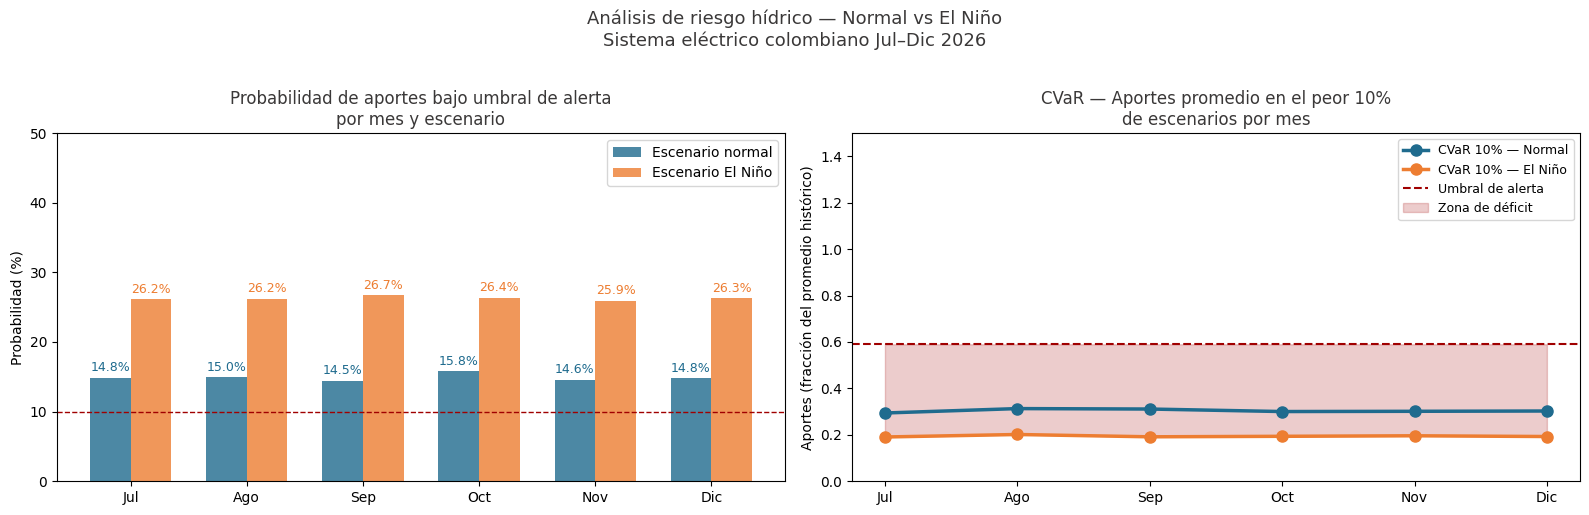


Resumen de riesgo:
Probabilidad promedio de crisis en año normal: 14.9%
Probabilidad promedio de crisis en El Niño:    26.3%


In [21]:
# Calcular probabilidad de caer bajo el umbral en cada escenario
umbral_alerta = 0.59

prob_critico_normal = (sim_normal < umbral_alerta).mean(axis=0) * 100
prob_critico_nino   = (sim_nino   < umbral_alerta).mean(axis=0) * 100

# CVaR simple — promedio del peor 10% de escenarios
cvar_normal = np.mean(np.sort(sim_normal, axis=0)[:int(N_simulaciones*0.10), :], axis=0)
cvar_nino   = np.mean(np.sort(sim_nino,   axis=0)[:int(N_simulaciones*0.10), :], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1 — Probabilidad de crisis por mes
x = np.arange(N_meses)
width = 0.35

bars1 = axes[0].bar(x - width/2, prob_critico_normal, width,
                     color='#1F6B8E', alpha=0.8, label='Escenario normal')
bars2 = axes[0].bar(x + width/2, prob_critico_nino, width,
                     color='#ED7D31', alpha=0.8, label='Escenario El Niño')

# Etiquetas encima de cada barra
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#1F6B8E')
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color='#ED7D31')

axes[0].set_xticks(x)
axes[0].set_xticklabels(meses)
axes[0].set_title('Probabilidad de aportes bajo umbral de alerta\npor mes y escenario',
                   fontsize=12, color='#3A3838')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_ylim(0, 50)
axes[0].legend()
axes[0].axhline(10, color='#A00000', linewidth=1,
                linestyle='--', label='Umbral de riesgo aceptable (10%)')

# Gráfica 2 — CVaR por mes
axes[1].plot(meses, cvar_normal, 'o-', color='#1F6B8E',
             linewidth=2.5, markersize=8, label='CVaR 10% — Normal')
axes[1].plot(meses, cvar_nino, 'o-', color='#ED7D31',
             linewidth=2.5, markersize=8, label='CVaR 10% — El Niño')
axes[1].axhline(umbral_alerta, color='#A00000', linewidth=1.5,
                linestyle='--', label='Umbral de alerta')
axes[1].fill_between(range(N_meses), cvar_nino, umbral_alerta,
                     where=(cvar_nino < umbral_alerta),
                     alpha=0.2, color='#A00000', label='Zona de déficit')

axes[1].set_title('CVaR — Aportes promedio en el peor 10%\nde escenarios por mes',
                   fontsize=12, color='#3A3838')
axes[1].set_ylabel('Aportes (fracción del promedio histórico)')
axes[1].set_ylim(0, 1.5)
axes[1].legend(fontsize=9)

plt.suptitle('Análisis de riesgo hídrico — Normal vs El Niño\n'
             'Sistema eléctrico colombiano Jul–Dic 2026',
             fontsize=13, color='#3A3838', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/riesgo_cvar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen de riesgo:")
print(f"Probabilidad promedio de crisis en año normal: {prob_critico_normal.mean():.1f}%")
print(f"Probabilidad promedio de crisis en El Niño:    {prob_critico_nino.mean():.1f}%")